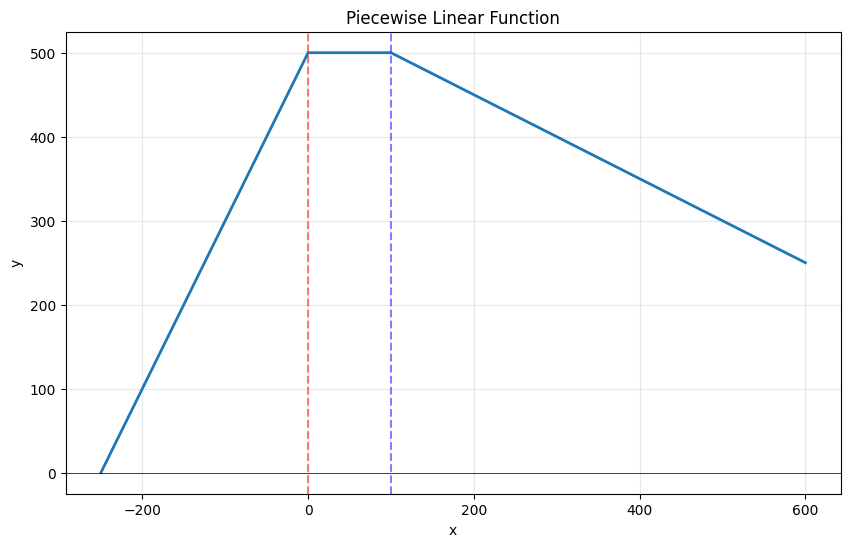

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define x ranges
x1 = np.linspace(-250, 0, 250)  # Increase phase
x2 = np.linspace(0, 100, 100)  # Constant phase
x3 = np.linspace(100, 600, 500)  # Decrease phase

# Define y values
increase_slope = 2
decrease_slope = 0.5

y1 = increase_slope * x1  # Increase
y2 = np.full_like(x2, increase_slope * 0)  # Constant at max value (0)
y3 = -decrease_slope * (x3 - 100)  # Decrease

# Combine arrays
x = np.concatenate([x1, x2, x3])
y = np.concatenate([y1, y2, y3])

# Shift y so minimum is at 0
y = y - y.min()

# Create plot
plt.figure(figsize=(10, 6))
plt.plot(x, y, linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Piecewise Linear Function')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5, label='x=0')
plt.axvline(x=100, color='b', linestyle='--', alpha=0.5, label='x=100')
plt.show()

c:\Users\biselli\.conda\envs\env_panteha\Lib\site-packages\numpy\lib\_function_base_impl.py:1290: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
c:\Users\biselli\.conda\envs\env_panteha\Lib\site-packages\numpy\lib\_function_base_impl.py:1291: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
c:\Users\biselli\.conda\envs\env_panteha\Lib\site-packages\numpy\lib\_function_base_impl.py:1292: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
c:\Users\biselli\.conda\envs\env_panteha\Lib\site-packages\numpy\lib\_function_base_impl.py:1298: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]


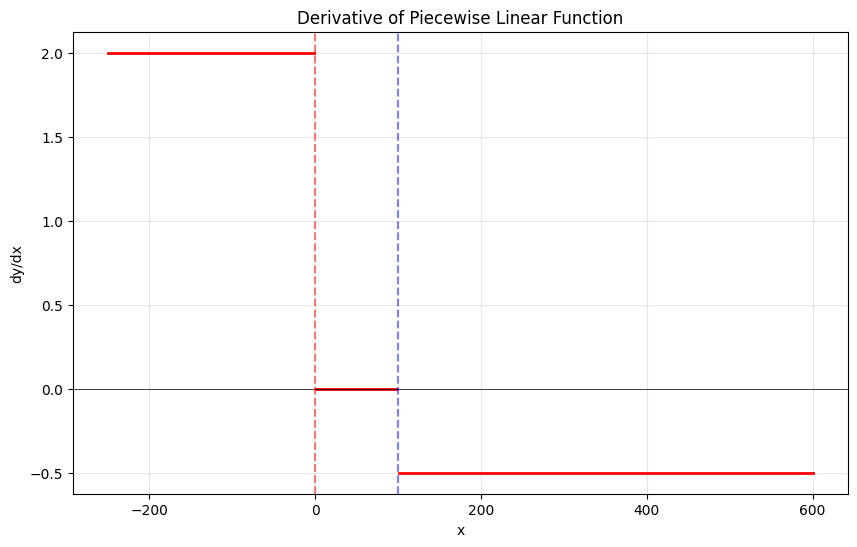

In [2]:
# Calculate the derivative using np.gradient
dy_dx = np.gradient(y, x)

# Create plot
plt.figure(figsize=(10, 6))
plt.plot(x, dy_dx, linewidth=2, color='red')
plt.xlabel('x')
plt.ylabel('dy/dx')
plt.title('Derivative of Piecewise Linear Function')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5, label='x=0')
plt.axvline(x=100, color='b', linestyle='--', alpha=0.5, label='x=100')
plt.show()

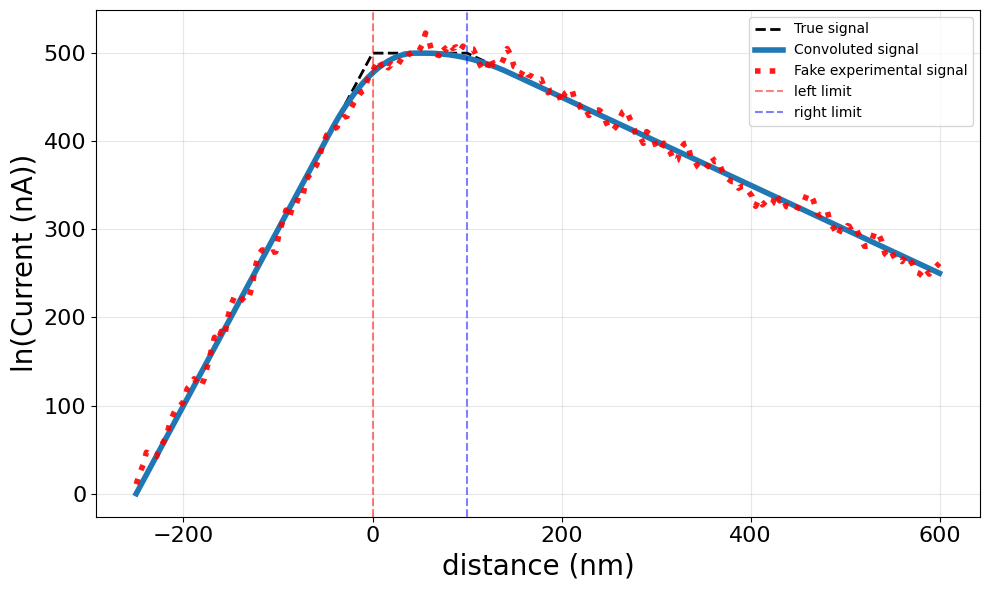

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Experimental sampling
# -----------------------------
dx_exp = 3.6
x_exp = np.arange(x.min(), x.max(), dx_exp)

y_true_exp = np.interp(x_exp, x, y)

# -----------------------------
# 2. Moving average with shrinking window
# -----------------------------
# -----------------------------
# 2. Moving average only in the center (Option 1)
# -----------------------------
window_size = 25
half_w = window_size // 2

y_conv = y_true_exp.copy()  # start with true values

# Apply moving average only in the safe zone (avoid edges)
for i in range(half_w, len(y_true_exp) - half_w):
    left = i - half_w
    right = i + half_w + 1
    y_conv[i] = np.mean(y_true_exp[left:right])

# -----------------------------
# 3. Add smooth experimental noise
# -----------------------------
np.random.seed(0)

noise_level = 0.03 * np.max(np.abs(y_conv))
raw_noise = np.random.normal(0, noise_level, size=len(y_conv))

noise_corr_len = 3
kernel_noise = np.ones(noise_corr_len) / noise_corr_len
smooth_noise = np.convolve(raw_noise, kernel_noise, mode='same')

y_noisy_exp = y_conv + smooth_noise

# -----------------------------
# 4. Plot (ONLY 3 CURVES) — improved visibility
# -----------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    x, y,
    color='black',
    linewidth=2,
    linestyle='--',
    label='True signal'
)

plt.plot(
    x_exp, y_conv,
    color='tab:blue',
    linewidth=4,
    linestyle='-',
    label='Convoluted signal'
)

plt.plot(
    x_exp, y_noisy_exp,
    color='red',
    linewidth=4,
    linestyle=':',
    alpha=0.9,
    label='Fake experimental signal'
)


# -----------------------------
# Formatting
# -----------------------------
plt.xlabel('distance (nm)', fontsize= 20)
plt.ylabel('ln(Current (nA))', fontsize= 20)
plt.xticks(fontsize= 16)
plt.yticks(fontsize= 16)
# plt.title('Moving average with reduced window at boundaries', fontsize= 20)
plt.grid(True, alpha=0.3)

plt.axvline(0, color='r', linestyle='--', alpha=0.5, label='left limit')
plt.axvline(100, color='b', linestyle='--', alpha=0.5, label='right limit')

plt.legend()
plt.tight_layout()
plt.show()


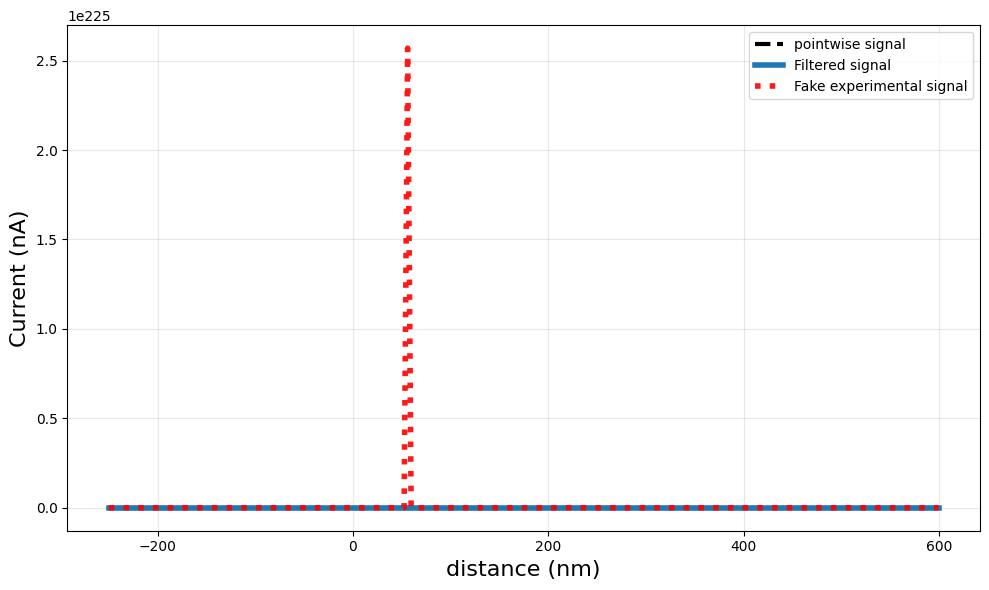

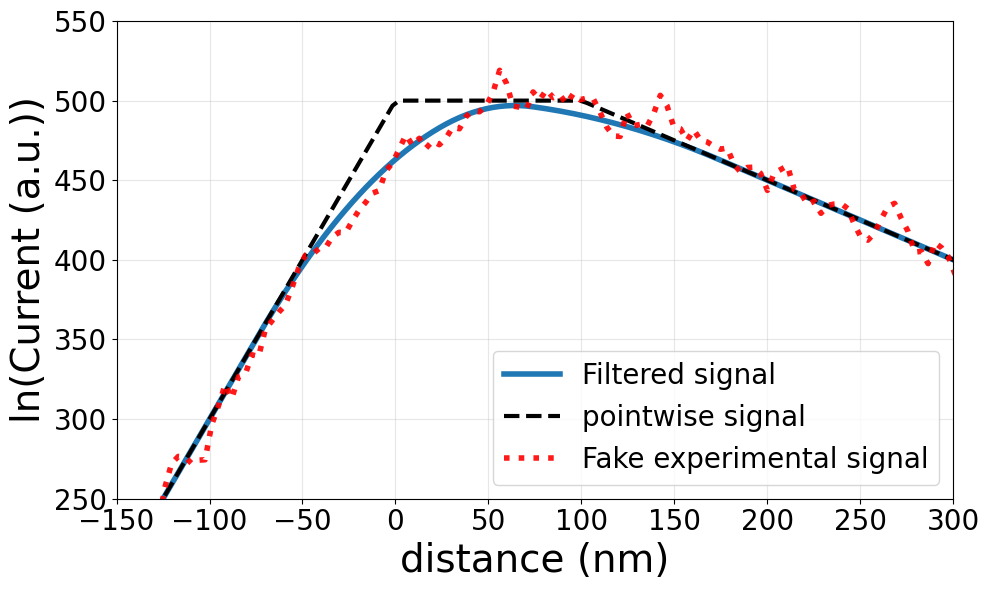

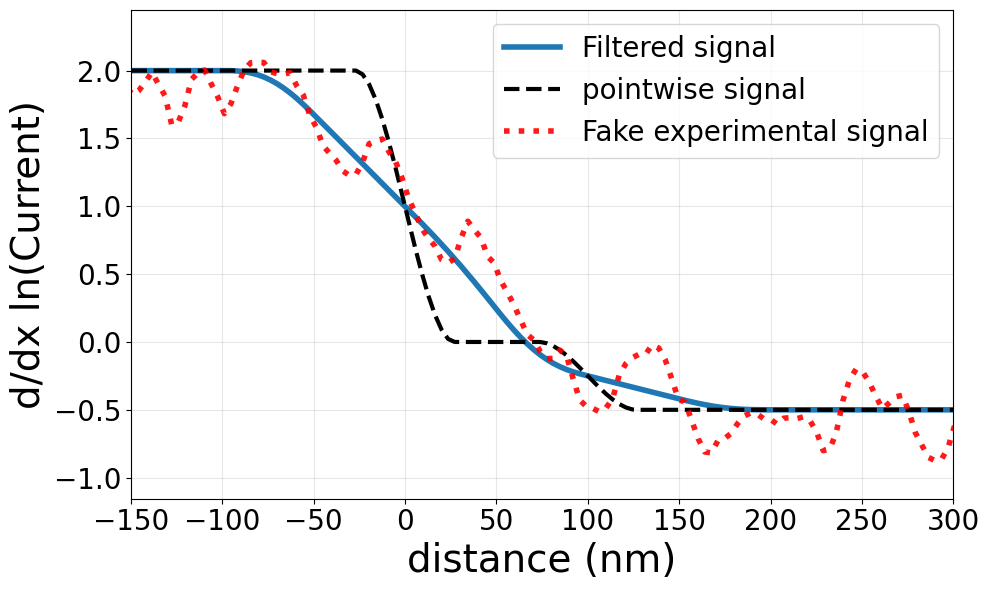

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 0. Example signals
# -----------------------------
dx_exp = 3.6
x_exp = np.arange(x.min(), x.max(), dx_exp)
y_true_exp = np.interp(x_exp, x, y)

# -----------------------------
# 1. Convoluted signal (moving average)
# -----------------------------
window_size = 40
half_w = window_size // 2
y_conv = y_true_exp.copy()
for i in range(half_w, len(y_true_exp) - half_w):
    y_conv[i] = np.mean(y_true_exp[i-half_w:i+half_w+1])

# -----------------------------
# 2. Fake experimental signal
# -----------------------------
np.random.seed(0)
noise_level = 0.03 * np.max(np.abs(y_conv))
raw_noise = np.random.normal(0, noise_level, size=len(y_conv))
y_noisy_exp = y_conv + np.convolve(raw_noise, np.ones(3)/3, mode='same')

# -----------------------------
# 3. Windowed numerical derivative function
# -----------------------------
def windowed_derivative(y_data, x_data, window_nm):
    dx_exp = x_data[1] - x_data[0]
    window_pts = int(np.round(window_nm / dx_exp))
    if window_pts % 2 == 0:
        window_pts += 1  # make odd for symmetry
    half_w = window_pts // 2

    deriv = np.zeros_like(y_data)

    for i in range(len(y_data)):
        # adaptive window at edges
        left = max(0, i - half_w)
        right = min(len(y_data), i + half_w + 1)
        x_window = x_data[left:right]
        y_window = y_data[left:right]

        # linear fit: slope = derivative
        A = np.vstack([x_window, np.ones(len(x_window))]).T
        slope, _ = np.linalg.lstsq(A, y_window, rcond=None)[0]
        deriv[i] = slope

    return deriv

# -----------------------------
# 4. Compute derivatives
# -----------------------------
grad_window_nm = 50
dy_dx_conv = windowed_derivative(y_conv, x_exp, grad_window_nm)
dy_dx_exp  = windowed_derivative(y_noisy_exp, x_exp, grad_window_nm)
dy_dx_true = windowed_derivative(y_true_exp, x_exp, grad_window_nm)

# -----------------------------
# 5. Define consistent line styles
# -----------------------------
true_style = {
    'color': 'black',
    'linewidth': 3,
    'linestyle': '--',
    'label': 'pointwise signal'
}

conv_style = {
    'color': 'tab:blue',
    'linewidth': 4,
    'linestyle': '-',
    'label': 'Filtered signal'
}

exp_style = {
    'color': 'red',
    'linewidth': 4,
    'linestyle': ':',
    'alpha': 0.9,
    'label': 'Fake experimental signal'
}

# -----------------------------
# 6. Linear plot (exp of signals)
# -----------------------------
plt.figure(figsize=(10,6))
plt.plot(x_exp, np.exp(y_true_exp), **true_style)
plt.plot(x_exp, np.exp(y_conv), **conv_style)
plt.plot(x_exp, np.exp(y_noisy_exp), **exp_style)
plt.xlabel('distance (nm)', fontsize=16)
plt.ylabel('Current (nA)', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 7. SEMILOG plot
# -----------------------------
plt.figure(figsize=(10,6))
plt.plot(x_exp, y_conv, **conv_style)
plt.plot(x_exp, y_true_exp, **true_style)
plt.plot(x_exp, y_noisy_exp, **exp_style)
plt.xlabel('distance (nm)', fontsize=28)
plt.ylabel('ln(Current (a.u.))', fontsize=28)
plt.xlim(-150,300)
plt.ylim(250,550)
plt.grid(True, alpha=0.3)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.tight_layout()
plt.show()

# -----------------------------
# 8. Derivative plot
# -----------------------------
plt.figure(figsize=(10,6))
plt.plot(x_exp, dy_dx_conv, **conv_style)
plt.plot(x_exp, dy_dx_true, **true_style)
plt.plot(x_exp, dy_dx_exp, **exp_style)
plt.xlabel('distance (nm)', fontsize=28)
plt.ylabel('d/dx ln(Current)', fontsize=28)
plt.grid(True, alpha=0.3)
plt.xlim(-150,300)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.tight_layout()
plt.show()


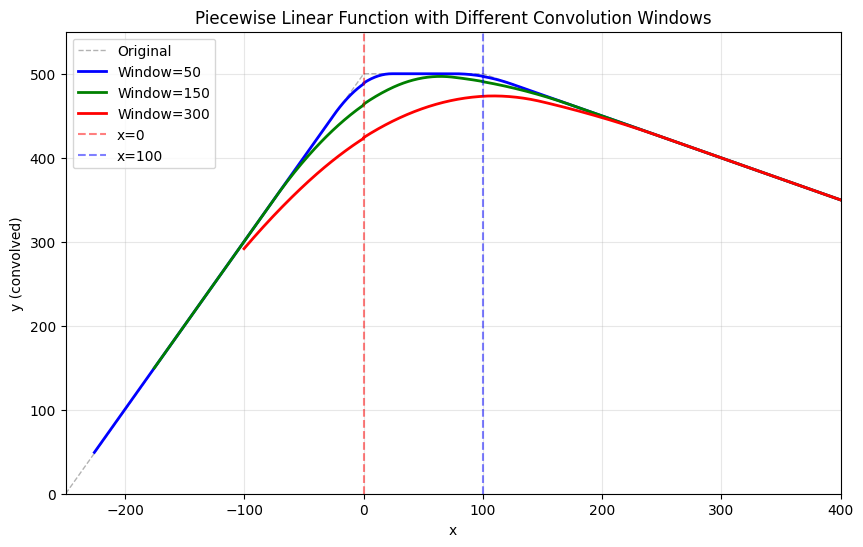

In [5]:
# Apply convolution with different window sizes
window_sizes = [50, 150, 300]

# Create plot
plt.figure(figsize=(10, 6))

# Plot original data
plt.plot(x, y, linewidth=1, alpha=0.3, label='Original', linestyle='--', color='black')

# Plot convolved data for each window size
colors = ['blue', 'green', 'red']
for i, window_size in enumerate(window_sizes):
    kernel = np.ones(window_size) / window_size
    y_conv_temp = np.convolve(y, kernel, mode='valid')
    x_conv_temp = x[(window_size-1)//2:-(window_size//2)]
    plt.plot(x_conv_temp, y_conv_temp, label=f'Window={window_size}', linewidth=2, color=colors[i])

plt.xlabel('x')
plt.xlim(-250, 400)
plt.ylabel('y (convolved)')
plt.ylim(000, 550)
plt.title('Piecewise Linear Function with Different Convolution Windows')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5, label='x=0')
plt.axvline(x=100, color='b', linestyle='--', alpha=0.5, label='x=100')
plt.legend()
plt.show()

# Store the window_size=200 results for use in the next cell
window_size = 200
kernel = np.ones(window_size) / window_size
y_conv = np.convolve(y, kernel, mode='valid')
x_conv = x[(window_size-1)//2:-(window_size//2)]

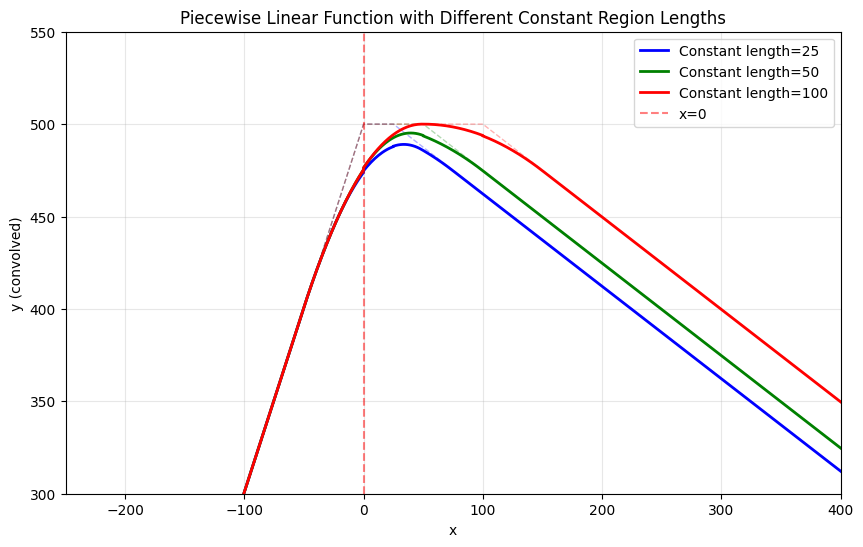

In [6]:
# Apply convolution with different constant region lengths
constant_lengths = [25, 50, 100]

# Create plot
plt.figure(figsize=(10, 6))

# Plot convolved data for each constant region length
colors = ['blue', 'green', 'red']
for i, const_len in enumerate(constant_lengths):
    # Define x ranges with varying constant region
    x1_temp = np.linspace(-250, 0, 250)
    x2_temp = np.linspace(0, const_len, const_len)
    x3_temp = np.linspace(const_len, const_len + 500, 500)
    
    # Define y values
    y1_temp = increase_slope * x1_temp
    y2_temp = np.full_like(x2_temp, increase_slope * 0)
    y3_temp = -decrease_slope * (x3_temp - const_len)
    
    # Combine arrays
    x_temp = np.concatenate([x1_temp, x2_temp, x3_temp])
    y_temp = np.concatenate([y1_temp, y2_temp, y3_temp])
    
    # Shift y so minimum is at 0
    y_temp = y_temp - y_temp.min()
    
    # Plot original data for this constant length
    plt.plot(x_temp, y_temp, linewidth=1, alpha=0.3, linestyle='--', color=colors[i])
    
    # Apply convolution
    window_size = 100
    kernel = np.ones(window_size) / window_size
    y_conv_temp = np.convolve(y_temp, kernel, mode='valid')
    x_conv_temp = x_temp[(window_size-1)//2:-(window_size//2)]
    
    plt.plot(x_conv_temp, y_conv_temp, label=f'Constant length={const_len}', linewidth=2, color=colors[i])

plt.xlabel('x')
plt.xlim(-250, 400)
plt.ylabel('y (convolved)')
plt.ylim(300, 550)
plt.title('Piecewise Linear Function with Different Constant Region Lengths')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5, label='x=0')
plt.legend()
plt.show()

# Store the constant_length=100 results for use in the next cell
const_len = 100
x1_temp = np.linspace(-250, 0, 250)
x2_temp = np.linspace(0, const_len, const_len)
x3_temp = np.linspace(const_len, const_len + 500, 500)
y1_temp = increase_slope * x1_temp
y2_temp = np.full_like(x2_temp, increase_slope * 0)
y3_temp = -decrease_slope * (x3_temp - const_len)
x_temp = np.concatenate([x1_temp, x2_temp, x3_temp])
y_temp = np.concatenate([y1_temp, y2_temp, y3_temp])
y_temp = y_temp - y_temp.min()
window_size = 200
kernel = np.ones(window_size) / window_size
y_conv = np.convolve(y_temp, kernel, mode='valid')
x_conv = x_temp[(window_size-1)//2:-(window_size//2)]

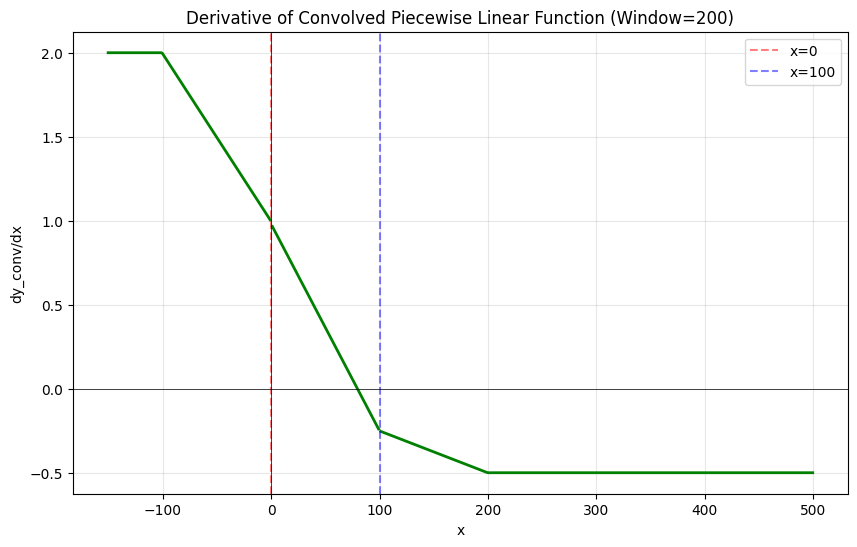

In [7]:
# Calculate the derivative of the convolved signal
dy_conv_dx = np.gradient(y_conv, x_conv)

# Create plot
plt.figure(figsize=(10, 6))
plt.plot(x_conv, dy_conv_dx, linewidth=2, color='green')
plt.xlabel('x')
plt.ylabel('dy_conv/dx')
plt.title(f'Derivative of Convolved Piecewise Linear Function (Window={window_size})')
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5, label='x=0')
plt.axvline(x=100, color='b', linestyle='--', alpha=0.5, label='x=100')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)
plt.show()

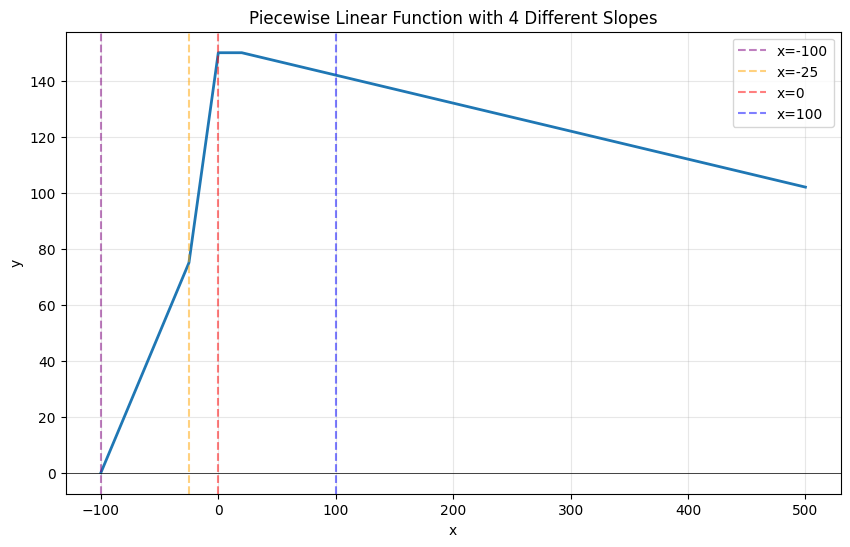

In [8]:
# Define x ranges with 4 different slopes
x1 = np.linspace(-100, -25, 75)   # First increasing slope
x2 = np.linspace(-25, 0, 25)      # More intense increasing slope
x3 = np.linspace(0, 20, 20)     # Constant phase
x4 = np.linspace(20, 500, 480)   # Decreasing slope (flatter than first)

# Define y values with different slopes
slope1 = 1.0           # First increase
slope2 = 3.0           # More intense increase
slope3 = 0.1           # Decrease (flatter than slope1)

y1 = slope1 * (x1 + 100)  # Start from 0 at x=-100
y2 = y1[-1] + slope2 * (x2 + 25)  # Continue from end of y1
y3 = np.full_like(x3, y2[-1])  # Constant at max value
y4 = y3[-1] - slope3 * (x4 - 20)  # Decrease from end of y3

# Combine arrays
x_new = np.concatenate([x1, x2, x3, x4])
y_new = np.concatenate([y1, y2, y3, y4])

# Shift y so minimum is at 0
y_new = y_new - y_new.min()

# Create plot
plt.figure(figsize=(10, 6))
plt.plot(x_new, y_new, linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Piecewise Linear Function with 4 Different Slopes')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=-100, color='purple', linestyle='--', alpha=0.5, label='x=-100')
plt.axvline(x=-25, color='orange', linestyle='--', alpha=0.5, label='x=-25')
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5, label='x=0')
plt.axvline(x=100, color='b', linestyle='--', alpha=0.5, label='x=100')
plt.legend()
plt.show()

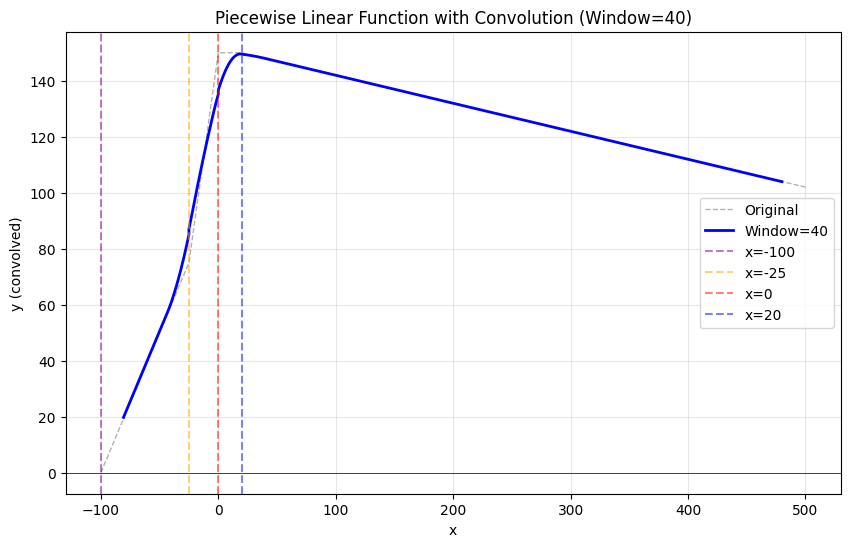

In [9]:
# Apply convolution to y_new with window size of 40
window_size = 40
kernel = np.ones(window_size) / window_size
y_new_conv = np.convolve(y_new, kernel, mode='valid')
x_new_conv = x_new[(window_size-1)//2:-(window_size//2)]

# Create plot
plt.figure(figsize=(10, 6))
plt.plot(x_new, y_new, linewidth=1, alpha=0.3, label='Original', linestyle='--', color='black')
plt.plot(x_new_conv, y_new_conv, label=f'Window={window_size}', linewidth=2, color='blue')
plt.xlabel('x')
plt.ylabel('y (convolved)')
plt.title(f'Piecewise Linear Function with Convolution (Window={window_size})')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=-100, color='purple', linestyle='--', alpha=0.5, label='x=-100')
plt.axvline(x=-25, color='orange', linestyle='--', alpha=0.5, label='x=-25')
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5, label='x=0')
plt.axvline(x=20, color='b', linestyle='--', alpha=0.5, label='x=20')
plt.legend()
plt.show()